# Choclo Norte — Test de Features XGBoost

**Diferencias clave vs Café Belén:**
- **Caso 3** (netear devoluciones) — igual que Café Belén
- **Sin filtro de cohortes** — creció 28% anual en nuevas sucursales, filtrar deja muy pocos datos
- **Sin capeo IQR** — no tiene outliers reales, sus picos son distribución normal
- **Semana Santa ayudó en el diagnóstico** — la probamos primero

**Lo que esperamos encontrar:** Semana Santa debería mejorar el SMAPE (~−1.5 puntos según diagnóstico previo).


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
try:
    import xgboost as xgb
    USE_XGB = True
    print("✅ XGBoost listo")
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB = False
    print("⚠️  Usando GradientBoostingRegressor")
print("✅ Imports OK")


✅ XGBoost listo
✅ Imports OK


## 2. Carga y preprocessing — Caso 3, sin cohorte, sin capeo

Registros: 6865 | Negativos: 90 | Ceros: 75

Límite IQR: 6148
Outliers detectados: 0
  → Sin outliers — NO se aplica capeo

Serie: 62 meses | Promedio: 2854 u/mes


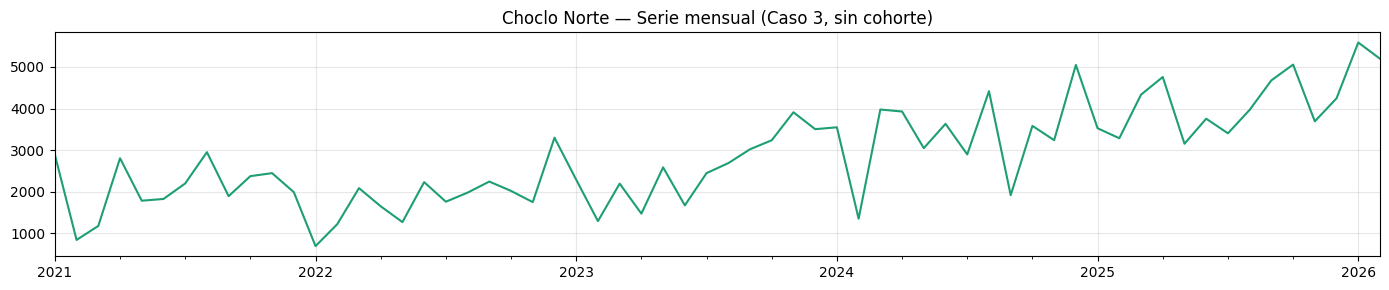


✅ Preprocessing listo.


In [2]:
ARCHIVO  = "G:\My Drive\ElCapstone\Capstone\clari\ChocloNorteTotal.xlsx"
PRODUCTO = 219140001

SEMANA_SANTA = {2021: 4, 2022: 4, 2023: 4, 2024: 3, 2025: 4, 2026: 4}

df = pd.read_excel(ARCHIVO, sheet_name="Datos Producto")
df["Mes"] = pd.to_datetime(df["Mes"])
df = df[df["Producto"] == PRODUCTO].copy()
df = df.sort_values(["NomClienteAlter", "Mes"]).reset_index(drop=True)

print(f"Registros: {len(df)} | Negativos: {(df['Demanda']<0).sum()} | Ceros: {(df['Demanda']==0).sum()}")

# CASO 3: netear devoluciones
for idx in df[df["Demanda"] < 0].index:
    cli   = df.loc[idx, "NomClienteAlter"]
    mes_d = df.loc[idx, "Mes"]
    dev   = df.loc[idx, "Demanda"]
    prev  = df[(df["NomClienteAlter"]==cli) & (df["Mes"]<mes_d)]
    if not prev.empty:
        pi = prev.index[-1]
        df.loc[pi, "Demanda"] = max(0, df.loc[pi, "Demanda"] + dev)
    df.loc[idx, "Demanda"] = 0

# SIN FILTRO DE COHORTES — todas las sucursales
ts = df.groupby("Mes")["Demanda"].sum().astype(float)
ts = ts.reindex(pd.date_range(ts.index.min(), ts.index.max(), freq="MS")).fillna(0.0)

# Verificar outliers IQR
Q1 = ts.quantile(0.25); Q3 = ts.quantile(0.75); IQR = Q3 - Q1
lim = Q3 + 1.5 * IQR
outliers = ts[ts > lim]
print(f"\nLímite IQR: {lim:.0f}")
print(f"Outliers detectados: {len(outliers)}")
if len(outliers):
    for f, v in outliers.items():
        print(f"  {f.strftime('%Y-%m')}: {v:.0f} (mes {f.month})")
    print("  → Verificar si son estacionalidad real antes de capear")
else:
    print("  → Sin outliers — NO se aplica capeo")

print(f"\nSerie: {len(ts)} meses | Promedio: {ts.mean():.0f} u/mes")

ts.plot(figsize=(14, 3), color="#1D9E75", title="Choclo Norte — Serie mensual (Caso 3, sin cohorte)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("\n✅ Preprocessing listo.")


## 3. Funciones base

In [3]:
def construir_modelo():
    if USE_XGB:
        return xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                 subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                                 reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbosity=0)
    return GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=4, subsample=0.8, random_state=42)

def features_base(ts):
    df = pd.DataFrame({"y": ts.astype(float)}).reset_index()
    df.columns = ["fecha", "y"]
    df["mes_num"]    = df["fecha"].dt.month
    df["trimestre"]  = df["fecha"].dt.quarter
    df["año"]        = df["fecha"].dt.year
    df["t"]          = range(len(df))
    df["t2"]         = df["t"] ** 2
    for lag in [1, 2, 3, 4, 6, 12, 13, 24]:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    for v in [3, 6, 12]:
        df[f"roll_mean_{v}"] = df["y"].shift(1).rolling(v).mean()
        df[f"roll_std_{v}"]  = df["y"].shift(1).rolling(v).std()
        df[f"roll_max_{v}"]  = df["y"].shift(1).rolling(v).max()
    df["yoy_change"]  = df["y"].shift(1) - df["y"].shift(13)
    df["yoy_ratio"]   = df["y"].shift(1) / (df["y"].shift(13) + 1)
    df["ratio_trend"] = (df["y"].shift(1).rolling(3).mean() /
                        (df["y"].shift(1).rolling(12).mean() + 1))
    df["diff_1"] = df["y"].diff(1)
    return df

def walk_forward(df_feat, min_train=24, ventana=36):
    fc = [c for c in df_feat.columns if c not in ["fecha", "y"]]
    X  = df_feat[fc].values
    y  = df_feat["y"].values
    fechas = df_feat["fecha"].values
    actuals, preds, dates = [], [], []
    for i in range(min_train, len(df_feat)):
        start = max(0, i - ventana)
        model = construir_modelo()
        model.fit(X[start:i], y[start:i])
        pred = max(0.0, float(model.predict(X[i:i+1])[0]))
        preds.append(pred)
        actuals.append(float(y[i]))
        dates.append(pd.Timestamp(fechas[i]))
    return np.array(actuals), np.array(preds), dates

def calcular_metricas(actuals, preds, label=""):
    mae   = mean_absolute_error(actuals, preds)
    rmse  = np.sqrt(mean_squared_error(actuals, preds))
    mask  = actuals > 0
    mape  = np.mean(np.abs((actuals[mask]-preds[mask])/actuals[mask]))*100
    smape = np.mean(2*np.abs(actuals-preds)/(np.abs(actuals)+np.abs(preds)+1e-9))*100
    bias  = np.mean(preds - actuals)
    ss_r  = np.sum((actuals-preds)**2)
    ss_t  = np.sum((actuals-actuals.mean())**2)
    r2    = 1 - ss_r/ss_t if ss_t > 0 else float("nan")
    return dict(label=label, SMAPE=smape, MAE=mae, RMSE=rmse, Bias=bias, R2=r2, n=len(actuals))

def imprimir_metricas(m):
    print(f"  SMAPE : {m['SMAPE']:>6.2f}%  ← métrica principal")
    print(f"  MAE   : {m['MAE']:>7.1f} unidades/mes")
    print(f"  Bias  : {m['Bias']:>+8.1f}  (+ sobreestima / - subestima)")
    print(f"  R²    : {m['R2']:>7.3f}")

print("✅ Funciones listas")


✅ Funciones listas


## 4. Prueba de features — una por una

> **Recordá:** para Choclo Norte el diagnóstico previo mostró que **Semana Santa ayudó (−1.5%)** y el capeo IQR empeoró. Eso es lo que esperamos confirmar acá.


### 4.0 — BASE

In [4]:
print("=" * 50)
print("  0. BASE — sin features adicionales")
print("=" * 50)
df0 = features_base(ts).dropna().reset_index(drop=True)
a0, p0, d0 = walk_forward(df0)
m0 = calcular_metricas(a0, p0, "0. Base")
imprimir_metricas(m0)
SMAPE_BASE = m0["SMAPE"]
print(f"\n  → Punto de referencia: {SMAPE_BASE:.2f}%")


  0. BASE — sin features adicionales
  SMAPE :  16.08%  ← métrica principal
  MAE   :   643.5 unidades/mes
  Bias  :   -414.3  (+ sobreestima / - subestima)
  R²    :  -0.063

  → Punto de referencia: 16.08%


### 4.1 — Semana Santa (mes variable)
**Por qué la probamos primero:** el diagnóstico previo mostró que es la feature que más ayuda a Choclo Norte. El choclo es un alimento básico — la gente compra más para las reuniones de Semana Santa.


In [5]:
print("=" * 50)
print("  1. + SEMANA SANTA (mes variable por año)")
print("=" * 50)
print(f"  Fechas: {SEMANA_SANTA}")

df1 = features_base(ts).copy()
df1["semana_santa"] = df1.apply(
    lambda r: 1 if SEMANA_SANTA.get(r["fecha"].year) == r["fecha"].month else 0, axis=1)
df1 = df1.dropna().reset_index(drop=True)
print(f"  Meses marcados: {df1['semana_santa'].sum()}")

a1, p1, d1 = walk_forward(df1)
m1 = calcular_metricas(a1, p1, "1. + Semana Santa")
imprimir_metricas(m1)

delta = SMAPE_BASE - m1["SMAPE"]
if delta > 0:   print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR")
elif delta < 0: print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR")
else:           print(f"\n  🔵 Sin cambio")


  1. + SEMANA SANTA (mes variable por año)
  Fechas: {2021: 4, 2022: 4, 2023: 4, 2024: 3, 2025: 4, 2026: 4}
  Meses marcados: 3
  SMAPE :  15.74%  ← métrica principal
  MAE   :   642.3 unidades/mes
  Bias  :   -399.4  (+ sobreestima / - subestima)
  R²    :  -0.024

  ✅ MEJORA de 0.34% → AGREGAR


### 4.2 — Navidad (nov-dic = 1)
**Por qué la probamos:** diciembre es el mes pico del Choclo Norte también. Probamos si el flag explícito ayuda.


In [6]:
print("=" * 50)
print("  2. + NAVIDAD (noviembre y diciembre = 1)")
print("=" * 50)

df2 = features_base(ts).copy()
df2["navidad"] = df2["fecha"].dt.month.isin([11, 12]).astype(int)
df2 = df2.dropna().reset_index(drop=True)

a2, p2, d2 = walk_forward(df2)
m2 = calcular_metricas(a2, p2, "2. + Navidad")
imprimir_metricas(m2)

delta = SMAPE_BASE - m2["SMAPE"]
if delta > 0:   print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR")
elif delta < 0: print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR")
else:           print(f"\n  🔵 Sin cambio")


  2. + NAVIDAD (noviembre y diciembre = 1)
  SMAPE :  15.77%  ← métrica principal
  MAE   :   643.8 unidades/mes
  Bias  :   -402.6  (+ sobreestima / - subestima)
  R²    :  -0.031

  ✅ MEJORA de 0.30% → AGREGAR


### 4.3 — Temporada alta (oct-dic = 1)
**Por qué la probamos:** flag más amplio que navidad, incluye octubre también.


In [7]:
print("=" * 50)
print("  3. + TEMPORADA ALTA (oct-nov-dic = 1)")
print("=" * 50)

df3 = features_base(ts).copy()
df3["temporada_alta"] = df3["fecha"].dt.month.isin([10, 11, 12]).astype(int)
df3 = df3.dropna().reset_index(drop=True)

a3, p3, d3 = walk_forward(df3)
m3 = calcular_metricas(a3, p3, "3. + Temporada alta")
imprimir_metricas(m3)

delta = SMAPE_BASE - m3["SMAPE"]
if delta > 0:   print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR")
elif delta < 0: print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR")
else:           print(f"\n  🔵 Sin cambio")


  3. + TEMPORADA ALTA (oct-nov-dic = 1)
  SMAPE :  15.82%  ← métrica principal
  MAE   :   644.5 unidades/mes
  Bias  :   -401.6  (+ sobreestima / - subestima)
  R²    :  -0.032

  ✅ MEJORA de 0.26% → AGREGAR


### 4.4 — Invierno paraguayo (jun-jul = 1)
**Por qué la probamos:** aunque el choclo no es un producto de invierno típico, probamos por completitud.


In [8]:
print("=" * 50)
print("  4. + INVIERNO (jun-jul = 1)")
print("=" * 50)

df4 = features_base(ts).copy()
df4["invierno"] = df4["fecha"].dt.month.isin([6, 7]).astype(int)
df4 = df4.dropna().reset_index(drop=True)

a4, p4, d4 = walk_forward(df4)
m4 = calcular_metricas(a4, p4, "4. + Invierno")
imprimir_metricas(m4)

delta = SMAPE_BASE - m4["SMAPE"]
if delta > 0:   print(f"\n  ✅ MEJORA de {delta:.2f}% → AGREGAR")
elif delta < 0: print(f"\n  ❌ EMPEORA {abs(delta):.2f}% → DESCARTAR")
else:           print(f"\n  🔵 Sin cambio")


  4. + INVIERNO (jun-jul = 1)
  SMAPE :  15.63%  ← métrica principal
  MAE   :   637.3 unidades/mes
  Bias  :   -397.6  (+ sobreestima / - subestima)
  R²    :  -0.010

  ✅ MEJORA de 0.45% → AGREGAR


### 4.5 — Mejor combinación

In [9]:
print("=" * 50)
print("  5. MEJOR COMBINACIÓN")
print("=" * 50)
print("  (editá esta celda según qué features mejoraron arriba)")

df5 = features_base(ts).copy()

# ── Descomentá solo las que MEJORARON ──
#df5["semana_santa"] = df5.apply(
#    lambda r: 1 if SEMANA_SANTA.get(r["fecha"].year) == r["fecha"].month else 0, axis=1)
#df5["navidad"]       = df5["fecha"].dt.month.isin([11, 12]).astype(int)
#df5["temporada_alta"]= df5["fecha"].dt.month.isin([10,11,12]).astype(int)
df5["invierno"]      = df5["fecha"].dt.month.isin([6, 7]).astype(int)
# ───────────────────────────────────────

df5 = df5.dropna().reset_index(drop=True)
a5, p5, d5 = walk_forward(df5)
m5 = calcular_metricas(a5, p5, "5. Mejor combinación")
imprimir_metricas(m5)

delta = SMAPE_BASE - m5["SMAPE"]
if delta > 0:   print(f"\n  ✅ MEJORA total de {delta:.2f}% vs base")
elif delta < 0: print(f"\n  ❌ Empeora {abs(delta):.2f}% — revisá qué feature suma ruido")
else:           print(f"\n  🔵 Sin cambio")


  5. MEJOR COMBINACIÓN
  (editá esta celda según qué features mejoraron arriba)
  SMAPE :  15.63%  ← métrica principal
  MAE   :   637.3 unidades/mes
  Bias  :   -397.6  (+ sobreestima / - subestima)
  R²    :  -0.010

  ✅ MEJORA total de 0.45% vs base


## 5. Tabla comparativa

In [10]:
todas = [m0, m1, m2, m3, m4, m5]
df_res = pd.DataFrame(todas)[["label","SMAPE","MAE","Bias","R2"]]
df_res = df_res.sort_values("SMAPE").reset_index(drop=True)
df_res.index += 1

print("=" * 65)
print("  RANKING — menor SMAPE = mejor")
print("=" * 65)
print(df_res.to_string(float_format=lambda x: f"{x:.2f}"))
print("=" * 65)

ganador = df_res.iloc[0]
print(f"\n🏆 MEJOR: {ganador['label']}")
print(f"   SMAPE: {ganador['SMAPE']:.2f}% | MAE: {ganador['MAE']:.1f} | Bias: {ganador['Bias']:+.1f}")
print(f"   Mejora vs base: {SMAPE_BASE - ganador['SMAPE']:+.2f}%")


  RANKING — menor SMAPE = mejor
                  label  SMAPE    MAE    Bias    R2
1  5. Mejor combinación  15.63 637.34 -397.62 -0.01
2         4. + Invierno  15.63 637.34 -397.62 -0.01
3     1. + Semana Santa  15.74 642.34 -399.40 -0.02
4          2. + Navidad  15.77 643.85 -402.63 -0.03
5   3. + Temporada alta  15.82 644.54 -401.55 -0.03
6               0. Base  16.08 643.50 -414.28 -0.06

🏆 MEJOR: 5. Mejor combinación
   SMAPE: 15.63% | MAE: 637.3 | Bias: -397.6
   Mejora vs base: +0.45%


## 6. Gráfico — real vs predicho

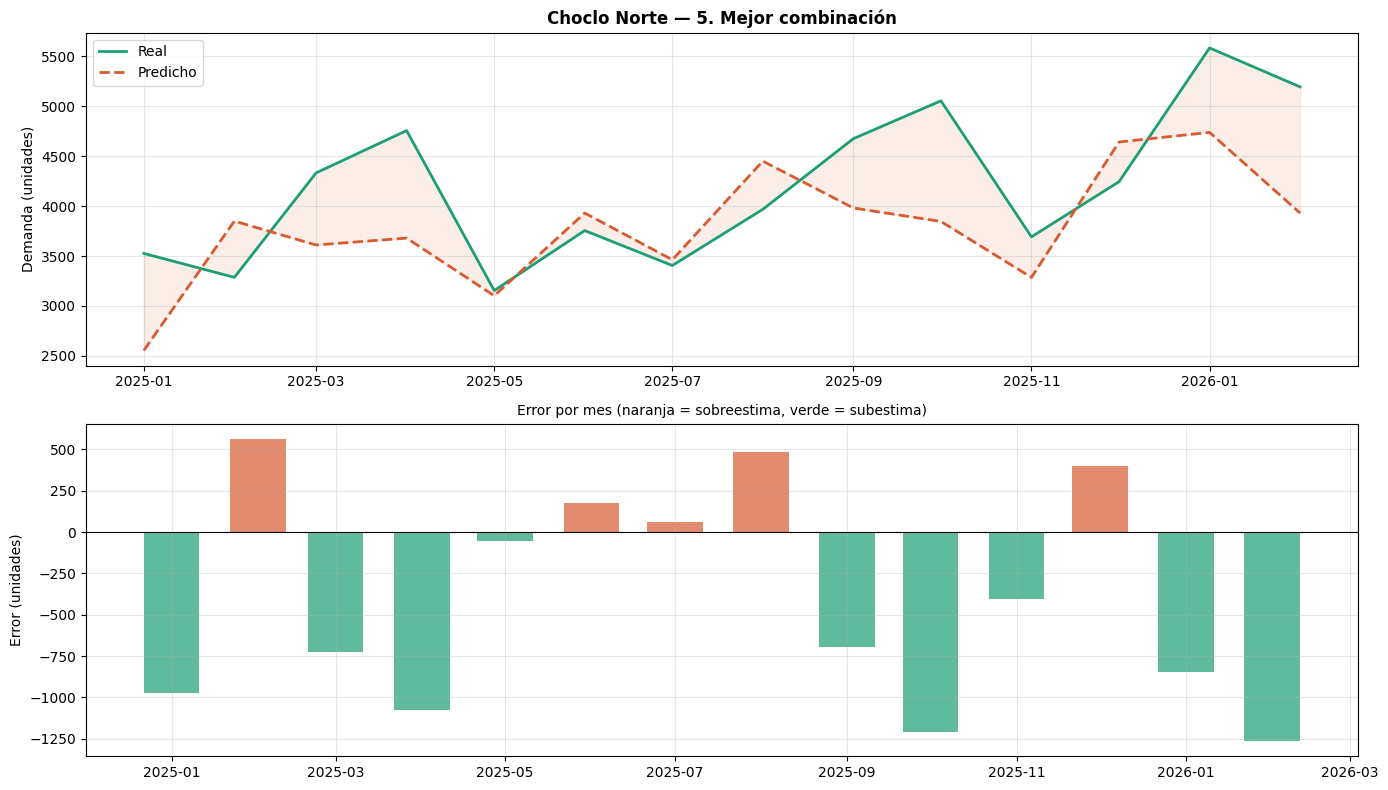

In [11]:
# Cambiá a5/p5/d5 por el número de la configuración ganadora
actuals_final, preds_final, dates_final = a5, p5, d5
label_final = m5["label"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(dates_final, actuals_final, label="Real", color="#1D9E75", linewidth=2)
axes[0].plot(dates_final, preds_final, label="Predicho", color="#D85A30",
             linewidth=2, linestyle="--")
axes[0].fill_between(dates_final, actuals_final, preds_final, alpha=0.1, color="#D85A30")
axes[0].set_title(f"Choclo Norte — {label_final}", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Demanda (unidades)")
axes[0].legend(); axes[0].grid(alpha=0.3)

errores = np.array(preds_final) - np.array(actuals_final)
colores = ["#D85A30" if e > 0 else "#1D9E75" for e in errores]
axes[1].bar(dates_final, errores, color=colores, alpha=0.7, width=20)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Error por mes (naranja = sobreestima, verde = subestima)", fontsize=10)
axes[1].set_ylabel("Error (unidades)"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Resumen — copiá esto al notebook de comparación final

In [12]:
m_final = m5  # ← cambiá por la mejor métrica

print("=" * 55)
print("  RESUMEN CHOCLO NORTE — para comparacion_final.ipynb")
print("=" * 55)
print(f"  Preprocessing : Caso 3 + sin cohorte + sin capeo IQR")
print(f"  Feature extra : {m_final['label']}")
print(f"  SMAPE  : {m_final['SMAPE']:.2f}%")
print(f"  MAE    : {m_final['MAE']:.1f} unidades/mes")
print(f"  RMSE   : {m_final['RMSE']:.1f}")
print(f"  Bias   : {m_final['Bias']:+.1f}")
print(f"  R²     : {m_final['R2']:.3f}")
print(f"  N      : {m_final['n']} meses evaluados")
print("=" * 55)


  RESUMEN CHOCLO NORTE — para comparacion_final.ipynb
  Preprocessing : Caso 3 + sin cohorte + sin capeo IQR
  Feature extra : 5. Mejor combinación
  SMAPE  : 15.63%
  MAE    : 637.3 unidades/mes
  RMSE   : 746.3
  Bias   : -397.6
  R²     : -0.010
  N      : 14 meses evaluados
